<a href="https://colab.research.google.com/github/JuanGonzalezb/Bootcamp-DS-Yasser_Stev_Rodriguez---Cohorte-202604/blob/main/Proyecto_Final_Diplomado_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Objetivo:**


Desarrollar un proyecto de ciencia de datos utilizando un conjunto de datos de libre elección. Deberás formular una pregunta de negocio o investigación y aplicar técnicas de análisis de datos y aprendizaje automático para responderla.

# **Predicción del precio de la acción NVIDIA**

1. Pregunta de Investigación

La pregunta se hará de una forma más práctica enfocada en resultados.

Queremos que el modelo prediga el precio del próximo día de la acción, y me diga, desde el día 0, cuánto está el precio y me ayude a definir si es bueno vender o comprar.

# **MODELADO SUPERVISADO**

Nos basaremos en **regresión** para predecir el precio y **clasificación** para decir si sube o baja.

In [ ]:
# Según internet, el mejor repositorio de datos históricos de acciones es Yahoo finanzas.
# Para extraer información de YAHOO FINANZAS, utilizaremos una librería especializada para ese tratamiento de datos.
# Vamos a utilizar y a instalar yfinance

In [ ]:
!pip install yfinance

In [ ]:
# Ahora importaremos las librerías

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score




# **DESCARGAR DATOS HISTÓRICOS DE NVIDIA **

Según internet, debemos utilizar un identificador en  Yahoo pa la acción. En este caso el identificador es (NVDA) para descargar el historial de precios en el rango de fechas deseado. vamos a utilizar un poco más de 1 año para tener una base sólida:

In [ ]:
# vamos a utilizar las fechas de ingreso como variables, para así poder evaluar de forma dinámica el modelo.

fecha_ini = input("Ingrese la fecha inicial (YYYY-MM-DD): ")
fecha_fin = input("Ingrese la fecha final (YYYY-MM-DD): ")


Ingrese la fecha inicial (YYYY-MM-DD): 2025-01-01
Ingrese la fecha final (YYYY-MM-DD): 2026-07-31


In [ ]:
#Utilizar la librería yf para traer el histórico.

ticker = "NVDA"
df_nvda = yf.download(ticker, start=fecha_ini, end=fecha_fin)

# Mostrar las primeras filas del DataFrame
df_nvda.head()


/tmp/ipykernel_3182/1595695358.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_nvda = yf.download(ticker, start=fecha_ini, end=fecha_fin)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2025-01-02,138.103745,138.672902,134.429240,135.797192,198247200
2025-01-03,144.254562,144.683914,139.521625,139.801207,229322500
2025-01-06,149.207138,151.933078,147.599554,148.368394,265377400
2025-01-07,139.931000,152.901632,139.801189,152.801775,351782200
2025-01-08,139.901047,143.735316,137.354847,142.367364,227349900


Verificar los datos descargados:

Vamos a comprobar el formato de las columnas (Open, High, Low, Close, Volume) y realizaremos una primera gráfica rápida para confirmar que el dataset se cargó correctamente:

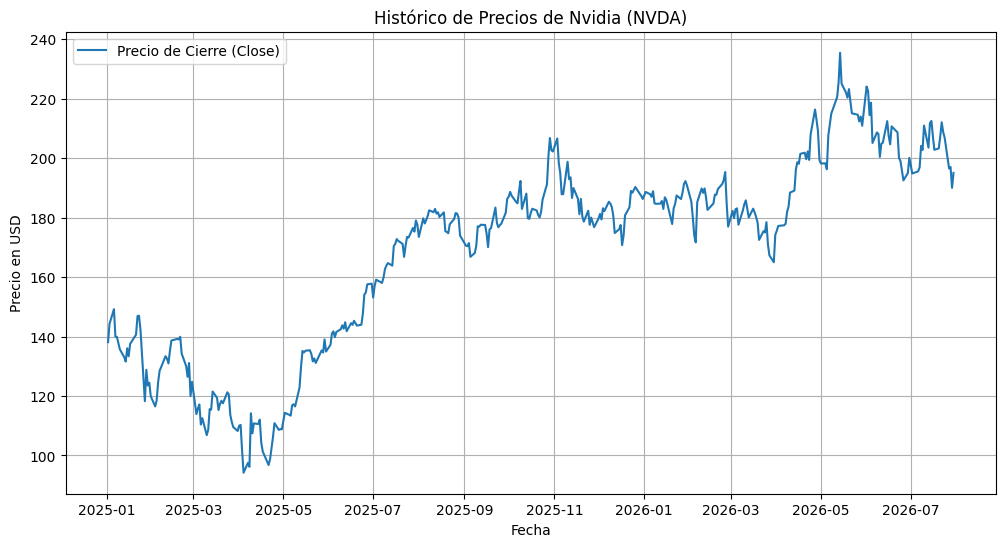

In [ ]:
# Graficar el precio de cierre
plt.figure(figsize=(12, 6))
plt.plot(df_nvda['Close'], label='Precio de Cierre (Close)')
plt.title('Histórico de Precios de Nvidia (NVDA)')
plt.xlabel('Fecha')
plt.ylabel('Precio en USD')
plt.legend()
plt.grid(True)
plt.show()

# **1. Exploración de los datos**

Realiza un análisis exploratorio del conjunto de datos que incluya:

    • Dimensiones del dataset.
    • Tipos de variables.
    • Valores nulos.
    • Registros duplicados.
    • Estadísticos descriptivos.
    • Visualizaciones que permitan comprender la información.

In [ ]:
# 1. Dimensiones del DataFrame (Filas, Columnas)
print("Estructura de los datos (Filas, Columnas):", df_nvda.shape)

# 2. Información sobre tipos de datos e índice
print("\n--- Información general ---")
df_nvda.info()

# 3. Verificación de valores nulos o faltantes
print("\n--- Valores nulos por columna ---")
print(df_nvda.isna().sum())

# 4. Resumen estadístico básico
print("\n--- Estadísticas descriptivas ---")
df_nvda.describe()

Estructura de los datos (Filas, Columnas): (394, 5)

--- Información general ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 394 entries, 2025-01-02 to 2026-07-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, NVDA)   394 non-null    float64
 1   (High, NVDA)    394 non-null    float64
 2   (Low, NVDA)     394 non-null    float64
 3   (Open, NVDA)    394 non-null    float64
 4   (Volume, NVDA)  394 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 18.5 KB

--- Valores nulos por columna ---
Price   Ticker
Close   NVDA      0
High    NVDA      0
Low     NVDA      0
Open    NVDA      0
Volume  NVDA      0
dtype: int64

--- Estadísticas descriptivas ---


Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
count,394.000000,394.000000,394.000000,394.000000,3.940000e+02
mean,169.025977,171.611151,166.252749,169.078911,2.001114e+08
std,32.346807,32.633309,32.246539,32.525996,8.332487e+07
min,94.178017,99.300842,86.498775,87.337596,6.552850e+07
25%,140.720573,143.314146,138.812967,141.976034,1.484539e+08
50%,179.466034,182.172728,176.145156,179.416107,1.797628e+08
75%,189.062088,192.942163,186.592428,190.934464,2.254939e+08
max,235.465576,236.264633,229.033071,229.602402,8.188309e+08


1. No tenemos datos nulos (viniendo de un dataset histórico y no un dataset para ejercicios).
2. Tenemos unas columnas de títulos sobrepuestas. Ahora trabajaremos en ello.
3. Formatos correcto para poder trabajar sin convertir datos.

# **PRIMERAS CONCLUSIONES**

Entre las fechas que escogimos, **hay alta volatilidad** Mirando el precio promedio de cierre de **169.026** y una desviación standar de **32.35** . Esta volatilidad nos puede ayudar para entrenar el modelo y que este mismo sea más interesante.

La columna **volume** nos dice cuántas acciones se transaron ese día. Hay un volumen alto y nos puede ayudar a ver qué tan atractiva y dinámica puede ser. Hay más de 200 millones de acciones transadas en promedio/día.





# **Vamos a ajustar las columnas**



In [ ]:
# Ajuste de las columnas dejándolo solo con el nombre del indicador
df_nvda.columns = df_nvda.columns.get_level_values(0)

# Verificacamos cómo quedan los nombres
print(df_nvda.head(2))

Price            Close        High         Low        Open     Volume
Date                                                                 
2025-01-02  138.103745  138.672902  134.429240  135.797192  198247200
2025-01-03  144.254562  144.683914  139.521625  139.801207  229322500


# **2. Preparación de los datos**

Realiza el preprocesamiento necesario para aplicar técnicas de clustering.

Debes justificar cada decisión tomada.
Por ejemplo:

    • Eliminación de variables irrelevantes.
    • Transformación del dataset para obtener variables por usuario.
    • Ingeniería de características (si aplica).
    • Escalamiento de variables.
    Importante: El dataset original se encuentra en formato de interacciones usuario–videojuego. Será necesario transformarlo para construir variables representativas de cada usuario antes de realizar el clustering.

## • **Eliminación de variables irrelevantes. **


En el dataset básico que vamos a utilizar, ninguna de las 5 variables es irrelevante. Todas aportan información fundamental sobre la dinámica del mercado:

Open, High, Low, Close: Definen el rango de precios, la volatilidad intra-día y el nivel de cierre.

Volume: Mide la liquidez y la fuerza detrás de cada movimiento de precio.

# **No eliminaremos variables.**

## • **Ingeniería de características. **


Teniendo una data tan plana y que solo me habla de tendencias o comprtamientos, y que solo tienen números, vamos a intentar crear variables que recomiendan en el mercado financiero:

1. Medias móviles y retornos.
2. Desviaciones estandar y variación de volúmenes.
3. Crear la variable objetivo.

# **Qué se hizo?:**

1. **Evitamos la fuga de datos:**

Usamos .shift(+1) para que la variable objetivo represente estrictamente lo que ocurrirá al día siguiente.

El modelo usará los datos de hoy ($t$) para predecir lo que pasará mañana ($t+1$).

**Balance de clases**: Al imprimir el porcentaje de Target_Class, comprobaremos si las clases (1 y 0) están equilibradas (~50% subidas, ~50% bajadas).

 Si están equilibradas,Las métricas estándar como Accuracy o ROC-AUC (Clasificación Binaria) funcionarán perfectamente.

In [ ]:


# Nos seguramos de tener una copia del trabajo para mantener intacto el DataFrame original
df_feat = df_nvda.copy()

# ==========================================
# 1. ING de características (Variables Predictoras)
# ==========================================

# Retornos diarios (Porcentaje de cambio de precio)
df_feat['Return_1d_Cambio_Precios_1D'] = df_feat['Close'].pct_change()

# Rango técnico relativo intradía (Volatilidad del día)
# (Precio alto-precio bajo)/precio de cierre
df_feat['High_Low_Pct_VolatilidadDia'] = (df_feat['High'] - df_feat['Low']) / df_feat['Close']

# Medias Móviles Simples (SMA) a 5 y 20 días.
# Hace el promedio de los ultimos 5 y 20 días del precio de cierre
df_feat['SMA_5'] = df_feat['Close'].rolling(window=5).mean()
df_feat['SMA_20'] = df_feat['Close'].rolling(window=20).mean()

# Distancia relativa del precio respecto a sus medias móviles (Momentum)
# Después de calcular las medias moviles simples, revisamos qué tan distanciadas están cada unos
# De los precios de cierre con las medias.
df_feat['Ratio_SMA5'] = df_feat['Close'] / df_feat['SMA_5']
df_feat['Ratio_SMA20'] = df_feat['Close'] / df_feat['SMA_20']

# Volatilidad móvil de 10 días calculada con la desvición estandar movil de los ultimos 10 días.
df_feat['Volatility_10d'] = df_feat['Return_1d_Cambio_Precios_1D'].rolling(window=10).std()

# Cambio porcentual en el volumen comercializado
df_feat['Volume_Change'] = df_feat['Volume'].pct_change()


# ==========================================
# 2. VARIABLES OBJETIVO (TARGETS)
# ==========================================

# A) TARGET PARA REGRESIÓN: El precio de cierre del DÍA SIGUIENTE (t+1)
df_feat['Target_Reg'] = df_feat['Close'].shift(-1)

# B) TARGET PARA CLASIFICACIÓN: 1 si el precio de mañana sube, 0 si baja/se mantiene
df_feat['Target_Class'] = (df_feat['Target_Reg'] > df_feat['Close']).astype(int)


# ==========================================
# 3. LIMPIEZA DE REGISTROS INCOMPLETOS
# ==========================================

# Eliminamos las filas con NaNs (causados por las ventanas de 20 días y el shift final)
df_ml = df_feat.dropna().copy()

print(f"Dimensiones finales del dataset procesado: {df_ml.shape}")
print("\nBalance de Clases para Clasificación (Target_Class):")
print(df_ml['Target_Class'].value_counts(normalize=True) * 100)

df_ml.head(3)

Dimensiones finales del dataset procesado: (374, 15)

Balance de Clases para Clasificación (Target_Class):
Target_Class
1    53.208556
0    46.791444
Name: proportion, dtype: float64


Price,Close,High,Low,Open,Volume,Return_1d_Cambio_Precios_1D,High_Low_Pct_VolatilidadDia,SMA_5,SMA_20,Ratio_SMA5,Ratio_SMA20,Volatility_10d,Volume_Change,Target_Reg,Target_Class
Date,,,,,,,,,,,,,,,
2025-01-31,119.890938,127.659334,119.012253,123.595404,388161100,-0.036743,0.072125,122.982324,135.520099,0.974863,0.884673,0.069586,-0.012125,116.486031,0
2025-02-03,116.486031,118.393178,112.841472,114.578875,371235700,-0.028400,0.047660,122.630850,134.439213,0.949892,0.866459,0.068386,-0.043604,118.473053,1
2025-02-04,118.473053,121.019245,116.525957,116.785571,256550000,0.017058,0.037927,120.565930,133.150138,0.982641,0.889770,0.068073,-0.308930,124.643845,1


# **DETECCION DE DATOS ATIPICOS**


En series temporales financieras, los valores atípicos (outliers) suelen corresponder a días de alta volatilidad (por ejemplo, presentaciones de resultados trimestrales o noticias macroeconómicas).



--- CONTEO DE OUTLIERS POR IQR ---
Columna 'Return_1d_Cambio_Precios_1D': 10 outliers detectados (2.67% del total)
Columna 'High_Low_Pct_VolatilidadDia': 17 outliers detectados (4.55% del total)
Columna 'Volatility_10d': 26 outliers detectados (6.95% del total)
Columna 'Volume_Change': 11 outliers detectados (2.94% del total)


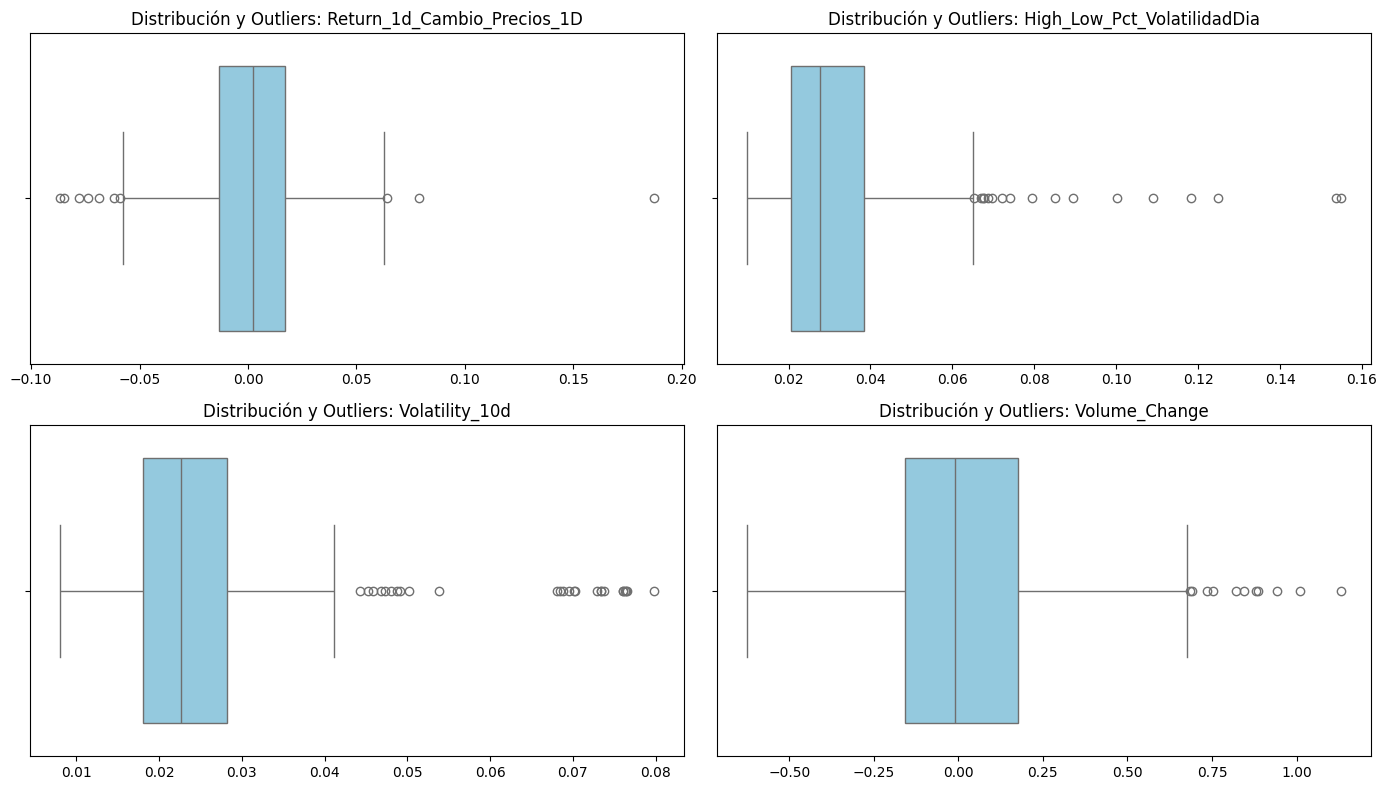

In [ ]:


# Seleccionamos las columnas numéricas donde nos interesa revisar outliers y hacemos una lista
cols_analisis = [
    'Return_1d_Cambio_Precios_1D',
    'High_Low_Pct_VolatilidadDia',
    'Volatility_10d',
    'Volume_Change'
]

# 1. Detección Estadística por Rango Intercuartílico (IQR)
print("--- CONTEO DE OUTLIERS POR IQR ---")
for col in cols_analisis:
    Q1 = df_ml[col].quantile(0.25)
    Q3 = df_ml[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    outliers = df_ml[(df_ml[col] < lim_inf) | (df_ml[col] > lim_sup)]
    pct = (len(outliers) / len(df_ml)) * 100
    print(f"Columna '{col}': {len(outliers)} outliers detectados ({pct:.2f}% del total)")

# 2. Visualización mediante Boxplots
plt.figure(figsize=(14, 8))
for i, col in enumerate(cols_analisis, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df_ml[col], color='skyblue')
    plt.title(f'Distribución y Outliers: {col}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

# **Análisis detallado por variable**


# **Return_1d_Cambio_Precios_1D (10 outliers - 2.67%):**

Comportamiento: Presenta una distribución simétrica centrada en 0, pero con cola hacia ambos lados (días con caídas de hasta el -9% y un día atípico con una subida cercana al +19%).

Interpretación financiera: Representa días de reacción extrema del mercado ante catalizadores clave (reportes de ganancias trimestrales o anuncios macroeconómicos).

# **High_Low_Pct_VolatilidadDia (17 outliers - 4.55%)**

Comportamiento: Fuerte sesgo positivo (a la derecha). La mayoría de los días el rango intradía está entre el 2% y el 4%, pero hay jornadas donde la fluctuación máxima-mínima superó el 12%-15%.

Interpretación financiera: Indica días con alta indecisión y fuerte turbulencia durante la sesión de negociación.

# **Volatility_10d (26 outliers - 6.95%)**

Comportamiento: Es la variable con mayor porcentaje de atípicos.

Interpretación financiera: Esto ocurre por construcción matemática: cuando hay un día con un retorno extremo, la ventana móvil de 10 días "arrastra" ese impacto durante los 10 días bursátiles siguientes, generando aglomeraciones (clusters) de alta volatilidad.

# **Volume_Change (11 outliers - 2.94%)**

Comportamiento: Presenta valores atípicos concentrados hacia la derecha, superando incrementos del 100% en el volumen negociado respecto al día anterior.


Interpretación financiera: Picos puntuales de liquidez masiva, típicos de días de vencimiento de opciones o eventos corporativos importantes.



**Por qué NO eliminamos estos valores:** En series temporales no se deben eliminar las filas con outliers. No se trata de errores de medición, sino de eventos reales de mercado. Borrarlos rompería la continuidad temporal de la serie y arruinaría el cálculo de las ventanas móviles (SMA_5, SMA_20) y el desfase del objetivo (shift(-1)).

# **5. MODELADO RUTA A ESCOGER**

**Ruta A – Aprendizaje Supervisado:**


El modelo analizará los patrones de $X$ en el pasado para aprender a predecir $y$, ajustando sus errores en función de la diferencia entre su predicción y el valor real registrado.




# **Selección del Escalador Ideal (RobustScaler):**

Dado que variables como Volatility_10d (6.95%) y High_Low_Pct_VolatilidadDia (4.55%) superan el umbral habitual de atípicos, el uso de StandardScaler (basado en media y desviación estándar) podría sesgar el rango de las variables. Por ello, la opción con mejor rigor técnico es **RobustScaler**, que utiliza la mediana y el rango intercuartílico (IQR) para escalar sin dejarse distorsionar por los valores extremos.

In [ ]:

# 1. Definición de variables independientes (X) y variables objetivo (y)
features = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'Return_1d_Cambio_Precios_1D', 'High_Low_Pct_VolatilidadDia',
    'SMA_5', 'SMA_20', 'Ratio_SMA5', 'Ratio_SMA20',
    'Volatility_10d', 'Volume_Change'
]

X = df_ml[features]
y_class = df_ml['Target_Class']  # Target Clasificación (0 o 1)
y_reg = df_ml['Target_Reg']      # Target Regresión (Precio $USD)

# 2. División Temporal Secuencial (80% Entrenamiento, 20% Prueba)
train_size = int(len(X) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

# Targets para Clasificación
y_train_class = y_class.iloc[:train_size]
y_test_class = y_class.iloc[train_size:]

# Targets para Regresión
y_train_reg = y_reg.iloc[:train_size]
y_test_reg = y_reg.iloc[train_size:]

# 3. Escalamiento Robusto (Resistente a Outliers)
scaler = RobustScaler()

# Se entrena y transforma SOLO con datos de Train
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=features, index=X_test.index)

print(f"Muestras de Entrenamiento (Train): {X_train_scaled.shape[0]}")
print(f"Muestras de Evaluación (Test): {X_test_scaled.shape[0]}")
print("¡División temporal y escalamiento completados!")

Muestras de Entrenamiento (Train): 299
Muestras de Evaluación (Test): 75
¡División temporal y escalamiento completados!


# **Entrenar el Primer Modelo de CLASIFICACIÓN**

Empezaremos con el enfoque de Clasificación Binaria para predecir la dirección del mercado (1 = Subida, 0 = Bajada). Entrenaremos un modelo de **Random Forest** Classifier (Bosques Aleatorios), que es sumamente robusto y adecuado para series financieras.

=== EVALUACIÓN DEL MODELO DE CLASIFICACIÓN (Random Forest) ===
Accuracy (Exactitud): 0.5200
ROC-AUC Score: 0.6728

Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

           0       0.51      1.00      0.68        38
           1       1.00      0.03      0.05        37

    accuracy                           0.52        75
   macro avg       0.76      0.51      0.37        75
weighted avg       0.75      0.52      0.37        75



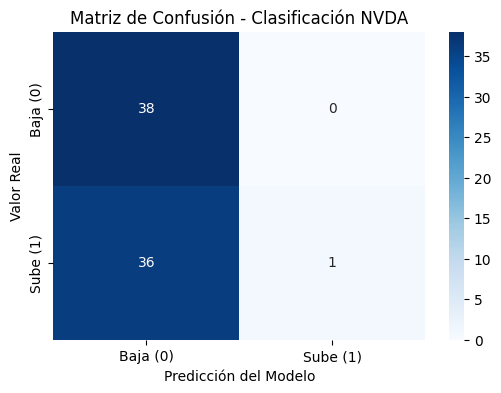

In [ ]:
# 1. Instanciar y Entrenar el Modelo
rf_class = RandomForestClassifier(n_estimators=100, random_state=42) #Usa 100 arboles de decisión , Usar el número 42 garantiza que el modelo genere la
# misma combinación exacta de datos y árboles
rf_class.fit(X_train_scaled, y_train_class)

# 2. Realizar Predicciones en el conjunto de prueba (Test)
y_pred_class = rf_class.predict(X_test_scaled)
y_pred_proba = rf_class.predict_proba(X_test_scaled)[:, 1]

# 3. Métricas de Evaluación
accuracy = accuracy_score(y_test_class, y_pred_class)
roc_auc = roc_auc_score(y_test_class, y_pred_proba)

print("=== EVALUACIÓN DEL MODELO DE CLASIFICACIÓN (Random Forest) ===")
print(f"Accuracy (Exactitud): {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}\n")
print("Reporte de Clasificación Detallado:")
print(classification_report(y_test_class, y_pred_class))

# 4. Matriz de Confusión
cm = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baja (0)', 'Sube (1)'],
            yticklabels=['Baja (0)', 'Sube (1)'])
plt.title('Matriz de Confusión - Clasificación NVDA')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()

# **CONCLUSIONES**

# **Accuracy = 52%  **

El modelo está muy 50/50, pero al observar la matriz de confusión, descubrimos que el modelo predijo "Baja" en 74 de los 75 días de prueba.

Dado que en el conjunto de prueba hubo 38 días de bajada y 37 de subida, predecir "Baja" a ciegas todos los días da matemáticamente un $38 / 75 = 50.67\%$ de acierto.

El modelo no aprendió a clasificar, solo adoptó una estrategia pasiva.

Recall de la Clase 1 (Sube) = 0.03 (3%)Es el punto más crítico: de 37 días reales donde la acción de Nvidia subió, el modelo solo fue capaz de detectar 1 día. Ignoró el 97% de las oportunidades de subida.


**ROC-AUC = 0.6842**

Un ROC-AUC de 0.6842 es superior a 0.50. Esto nos indica que las probabilidades internas que calcula Random Forest sí tienen cierto orden y señal predictiva, pero el umbral por defecto por el cual decide si es 1 o 0 (umbral estándar de $0.50$) es demasiado rígido para estos datos.

# **MODELO DE REGRESIÓN**


Para este modelo de regresión con datos financieros, vamos aestimar el precio de CIERRE y a utilizar las siguientes metricas.

* MAE (Mean Absolute Error): El error promedio directo en dólares.

* RMSE (Root Mean Squared Error): Penaliza con mayor severidad los errores o desviaciones grandes.

* $R^2$ Score (Coeficiente de Determinación): Qué porcentaje de la variancia del precio logra explicar el modelo.





# **Entrenamiento del modelo**

Probaremos dos enfoques fundamentales para comparar:

* **Regresión Lineal** (LinearRegression): Un modelo base simple y muy interpretable.

* **Bosques Aleatorios para Regresión** (RandomForestRegressor): Un algoritmo basado en ensambles capaz de capturar relaciones complejas no lineales.





In [ ]:
# 1. Entrenar Modelo 1: Regresión Lineal
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_reg)
y_pred_lr = lr_model.predict(X_test_scaled)

# 2. Entrenar Modelo 2: Random Forest Regressor
rf_reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg_model.fit(X_train_scaled, y_train_reg)
y_pred_rf = rf_reg_model.predict(X_test_scaled)

# 3. Función para calcular y mostrar métricas
def evaluar_regresion(nombre, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    print(f"=== METRICAS: {nombre} ===")
    print(f"MAE  (Error Absoluto Medio): ${mae:.2f} USD")
    print(f"RMSE (Raíz Error Cuadrático): ${rmse:.2f} USD")
    print(f"R²   (Coeficiente Determinación): {r2:.4f}\n")

evaluar_regresion("Regresión Lineal", y_test_reg, y_pred_lr)
evaluar_regresion("Random Forest Regressor", y_test_reg, y_pred_rf)

=== METRICAS: Regresión Lineal ===
MAE  (Error Absoluto Medio): $4.25 USD
RMSE (Raíz Error Cuadrático): $5.43 USD
R²   (Coeficiente Determinación): 0.6647

=== METRICAS: Random Forest Regressor ===
MAE  (Error Absoluto Medio): $10.64 USD
RMSE (Raíz Error Cuadrático): $13.07 USD
R²   (Coeficiente Determinación): -0.9453



# **Gráfica Comparativa (Precio Real vs. Precio Predicho)**



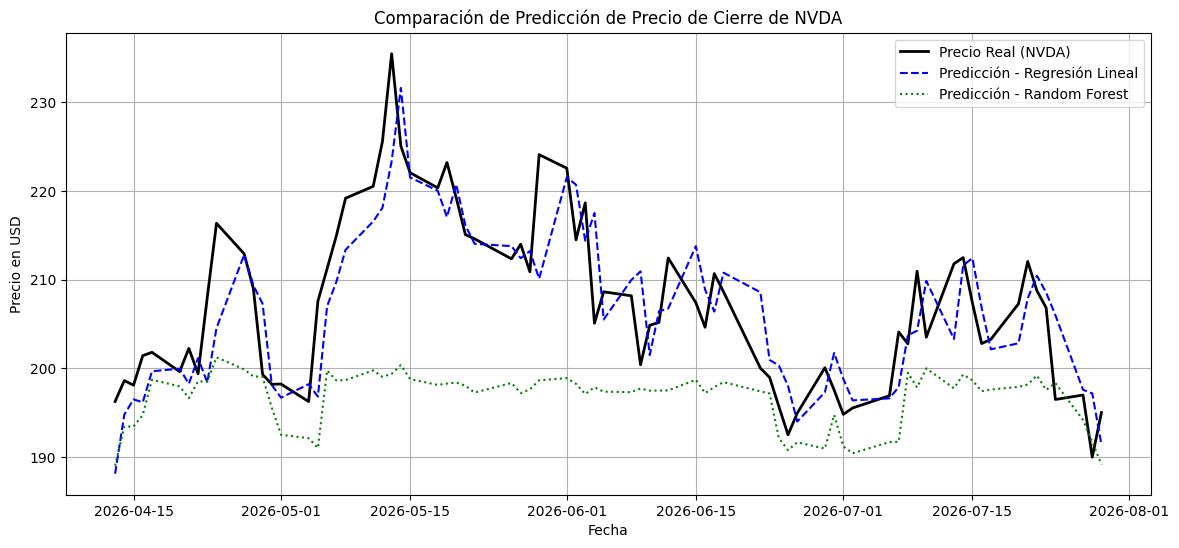

In [ ]:
# Gráfica de comparación en el conjunto de prueba (Test)
plt.figure(figsize=(14, 6))

plt.plot(y_test_reg.index, y_test_reg.values, label='Precio Real (NVDA)', color='black', linewidth=2)
plt.plot(y_test_reg.index, y_pred_lr, label='Predicción - Regresión Lineal', color='blue', linestyle='--')
plt.plot(y_test_reg.index, y_pred_rf, label='Predicción - Random Forest', color='green', linestyle=':')

plt.title('Comparación de Predicción de Precio de Cierre de NVDA')
plt.xlabel('Fecha')
plt.ylabel('Precio en USD')
plt.legend()
plt.grid(True)
plt.show()

# **Comparativa de MétricasRegresión Lineal (Más Óptimo ):**

**$MAE** = \$4.25\text{ USD}$: En promedio, el error absoluto del modelo es de solo $4.25 por acción.

**$RMSE **= \$5.43\text{ USD}$: Un error cuadrático cercano al MAE indica que no comete desviaciones catastróficas ni errores extremos aislados.

**$R^2** = 0.6647$: Logra explicar el 66.47% de la varianza del precio del día siguiente en el conjunto de prueba.

# **Random Forest Regressor (No tan óptimo):**

**$MAE** = \$10.64\text{ USD}$: Más del doble de error absoluto que la Regresión Lineal.

**$RMSE** = \$13.07\text{ USD}$: Sensible a picos de diferencia.

**$R^2 **= -0.9453$: Un $R^2$ negativo demuestra que el modelo es técnicamente peor que simplemente predecir el valor promedio histórico.

# **¿Por qué falló Random Forest?**


* **Incapacidad de Extrapolación en Árboles de Decisión**:

Los modelos basados en árboles (como Random Forest) dividen el espacio de búsqueda en "cajas" (umbrales).

Si el precio de Nvidia durante el periodo de prueba alcanza niveles superiores a los vistos en la fase de entrenamiento, el árbol es incapaz de extrapolar hacia arriba.Por eso la línea verde se queda "plana" alrededor de los $\$195-\$200\text{ USD}$: el algoritmo está asignando el valor máximo que memorizó durante el entrenamiento.


* **Proyección Continua de la Regresión Lineal:**


La Regresión Lineal asigna pesos (coeficientes) a variables como SMA_5, SMA_20 y Close. Cuando estas variables crecen en el test, la ecuación matemática simplemente proyecta ese crecimiento de manera continua, permitiéndole acompañar la tendencia alcista.





# **CONCLUSIONES**



* Para Clasificación: Los algoritmos no lograron predecir la dirección (subida/bajada) debido al alto nivel de ruido e ineficiencia del mercado a corto plazo (el azar de fluctuaciones diarias impidió superar el ~52% de exactitud).

* Para Regresión: La Regresión Lineal demostró ser superior a modelos complejos no lineales ($R^2 = 0.6647$), debido a la capacidad de extrapolación matemática que carecen los ensambles de árboles en activos con tendencias alcistas fuertes.